# Imports and setup

In [31]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("reshape2")

library(sqldf)
library(dplyr)
library(ggplot2)
library(reshape2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Load Data

In [32]:
base <- "https://raw.githubusercontent.com/samko945/northstar_dataset/refs/heads/main/cleaned/"

# These CSVs were produced by the Python notebook
# deliveries_cleaned includes two engineered columns added during that process:
#   - is_failed: 1 if delivery_status == "Failed", 0 otherwise.
#     Stored as 0/1 so it can be used in SUM() and AVG() aggregations directly.
#   - dispatch_month: year-month string (e.g. "2024-06") extracted from dispatch_time,
#     used to group deliveries by month.
deliveries <- read.csv(paste0(base, "deliveries_cleaned.csv"), stringsAsFactors = FALSE)
orders <- read.csv(paste0(base, "orders_cleaned.csv"), stringsAsFactors = FALSE)
drivers <- read.csv(paste0(base, "drivers_cleaned.csv"), stringsAsFactors = FALSE)
hubs <- read.csv(paste0(base, "hubs_cleaned.csv"), stringsAsFactors = FALSE)
complaints <- read.csv(paste0(base, "complaints_cleaned.csv"), stringsAsFactors = FALSE)
customers <- read.csv(paste0(base, "customers_cleaned.csv"), stringsAsFactors = FALSE)
vehicles <- read.csv(paste0(base, "vehicles_cleaned.csv"), stringsAsFactors = FALSE)
app_events <- read.csv(paste0(base, "app_events_cleaned.csv"), stringsAsFactors = FALSE)
incidents <- read.csv(paste0(base, "incidents_cleaned.csv"), stringsAsFactors = FALSE)

cat("Row counts:\n")
cat("deliveries:", nrow(deliveries), "\n")
cat("orders:", nrow(orders), "\n")
cat("drivers:", nrow(drivers), "\n")
cat("hubs:", nrow(hubs), "\n")
cat("complaints:", nrow(complaints), "\n")
cat("customers:", nrow(customers), "\n")
cat("vehicles:", nrow(vehicles), "\n")
cat("app_events:", nrow(app_events), "\n")
cat("incidents:", nrow(incidents), "\n")

Row counts:
deliveries: 950 
orders: 1250 
drivers: 170 
hubs: 8 
complaints: 320 
customers: 650 
vehicles: 120 
app_events: 640 
incidents: 280 


### Q1: Overall delivery volumes and operating costs

In [33]:
# delivery cost and distance columns
summary(deliveries[, c("fuel_or_charge_cost", "route_distance_km", "is_failed")])

 fuel_or_charge_cost route_distance_km   is_failed     
 Min.   : 2.500      Min.   : 1.200    Min.   :0.0000  
 1st Qu.: 9.925      1st Qu.: 9.135    1st Qu.:0.0000  
 Median :12.645      Median :12.840    Median :0.0000  
 Mean   :12.841      Mean   :13.909    Mean   :0.1389  
 3rd Qu.:15.697      3rd Qu.:16.835    3rd Qu.:0.0000  
 Max.   :29.430      Max.   :41.940    Max.   :1.0000  

In [34]:
q1 <- sqldf("
  SELECT COUNT(*) AS total_deliveries,
         SUM(is_failed) AS total_failed,
         ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_cost,
         ROUND(AVG(route_distance_km), 1) AS avg_distance_km
  FROM deliveries
")

print(q1)

  total_deliveries total_failed avg_fuel_cost avg_distance_km
1              950          132         12.84            13.9


With a total of 950 recorded deliveries, 132 were unsuccessful, and a failure rate of 13.9%. The average fuel or cost per delivery is £12.84, and the average route covers 13.9 km. These figures provide a baseline when comparing individual hubs or service types against the overall operation.

### Q2: Complaint volume and compensation by type

In [35]:
# Explore the complaints table
cat("complaints columns:", paste(names(complaints), collapse = ", "), "\n\n")
cat("Unique complaint types:\n")
print(unique(complaints$complaint_type))

complaints columns: complaint_id, customer_id, order_id, complaint_type, channel, severity, created_at, status, resolution_days, compensation_amount 

Unique complaint types:
[1] "AppIssue"          "MissedPickup"      "Delay"            
[4] "DriverBehaviour"   "Billing"           "Damage"           
[7] "SupportExperience"


In [36]:
q2 <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total_complaints,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation,
         ROUND(SUM(compensation_amount), 2) AS total_compensation
  FROM complaints
  WHERE complaint_type IS NOT NULL
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
")

print(q2)

     complaint_type total_complaints avg_compensation total_compensation
1             Delay              101            16.80            1696.84
2      MissedPickup               64            22.24            1423.40
3          AppIssue               53            18.50             980.72
4   DriverBehaviour               51            19.08             973.06
5 SupportExperience               20            17.13             342.50
6           Billing               16            23.87             381.94
7            Damage               15            23.98             359.73


Delays are by far the most common complaint NorthStar receives, accounting for 101 cases and a total of £1,696 in compensation paid out. Missed pickups are the second most frequent issue. Although Billing and Damage complaints are relatively rare, they cost around £24 per case on average, the highest of any category, so even a small number of these incidents has a meaningful impact.

### Q3: Delivery failure rate by hub

In [37]:
# Check the structure of the deliveries and hubs tables before querying
cat("deliveries columns:", paste(names(deliveries), collapse = ", "), "\n\n")
cat("hubs columns:", paste(names(hubs), collapse = ", "), "\n\n")
head(hubs)

deliveries columns: delivery_id, order_id, driver_id, vehicle_id, hub_id, dispatch_time, delivery_completed_at, delivery_status, route_distance_km, manual_route_override_count, proof_of_completion_missing, customer_rating_post_delivery, fuel_or_charge_cost, is_failed, dispatch_month 

hubs columns: hub_id, hub_name, zone, hub_type, capacity_score 



,hub_id,hub_name,zone,hub_type,capacity_score
,<chr>,<chr>,<chr>,<chr>,<int>
1,H01,North Exchange,north,Dispatch,82
2,H02,South Link,south,Dispatch,78
3,H03,East Dock,east,Warehouse,74
4,H04,West Gate,west,Dispatch,69
5,H05,Central Core,central,Control,88
6,H06,Airport Hub,airport,Dispatch,71


In [38]:
q3 <- sqldf("
  SELECT d.hub_id,
         h.hub_name,
         h.zone,
         COUNT(*) AS total_deliveries,
         SUM(d.is_failed) AS total_failed,
         ROUND(100.0 * SUM(d.is_failed) / COUNT(*), 1) AS fail_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone
  ORDER BY fail_rate_pct DESC
")

print(q3)

  hub_id       hub_name      zone total_deliveries total_failed fail_rate_pct
1    H08  Midtown Relay   central              128           26          20.3
2    H05   Central Core   central              115           23          20.0
3    H06    Airport Hub   airport              104           15          14.4
4    H04      West Gate      west              127           16          12.6
5    H01 North Exchange     north              136           17          12.5
6    H07  Riverside Hub riverside              115           14          12.2
7    H02     South Link     south              106           10           9.4
8    H03      East Dock      east              119           11           9.2


The central zone hubs, Midtown Relay (H08) and Central Core (H05) are underperforming, with around one in five deliveries failing. This is roughly double the failure rate seen at South Link and East Dock, which sit below 10%. The pattern suggests the central zone has a structural problem rather than isolated incidents, and would be the most logical place to focus operational improvements first.

### Q4: Failure rate and average order value by service type

In [39]:
# Check service types available in the orders table and preview a few rows
cat("Unique service types:\n")
print(table(orders$service_type))
cat("\n")
head(orders[, c("order_id", "service_type", "order_value")], 5)

Unique service types:

 Business   Medical    Parcel Passenger    Retail 
      165       139       308       341       297 



,order_id,service_type,order_value
,<chr>,<chr>,<dbl>
1,O00001,Passenger,126.65
2,O00002,Passenger,109.30
3,O00003,Passenger,33.50
4,O00004,Parcel,10.04
5,O00005,Retail,125.58


In [40]:
q4 <- sqldf("
  SELECT o.service_type,
         COUNT(d.delivery_id) AS total,
         SUM(d.is_failed) AS failed,
         ROUND(100.0 * SUM(d.is_failed) / COUNT(*), 1) AS fail_rate_pct,
         ROUND(AVG(o.order_value), 2) AS avg_order_value,
         ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_cost
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY fail_rate_pct DESC
")

print(q4)

  service_type total failed fail_rate_pct avg_order_value avg_fuel_cost
1     Business   126     25          19.8           97.45         13.14
2      Medical   108     16          14.8           86.53         12.77
3    Passenger   262     38          14.5           97.19         12.40
4       Retail   224     28          12.5           86.81         12.97
5       Parcel   230     25          10.9           90.15         13.08


Business deliveries have the highest failure rate at 19.8%, despite also having the highest average order value (£97.45). The most valuable service type is also the least reliable. Parcel deliveries perform best, failing in just 10.9% of cases. Fuel costs are similar across all service types (around £12–13), so the differences in failure rate appear to be driven by factors other than route cost.

### Q5: Hubs exceeding 15% delivery failure rate

In [41]:
# Preview results to identify which hubs might exceed the threshold
print(q3[, c("hub_name", "zone", "fail_rate_pct")])

        hub_name      zone fail_rate_pct
1  Midtown Relay   central          20.3
2   Central Core   central          20.0
3    Airport Hub   airport          14.4
4      West Gate      west          12.6
5 North Exchange     north          12.5
6  Riverside Hub riverside          12.2
7     South Link     south           9.4
8      East Dock      east           9.2


In [42]:
q5 <- sqldf("
  SELECT d.hub_id,
         h.hub_name,
         h.zone,
         COUNT(*) AS total_deliveries,
         SUM(d.is_failed) AS total_failed,
         ROUND(100.0 * SUM(d.is_failed) / COUNT(*), 1) AS fail_rate_pct
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone
  HAVING fail_rate_pct > 15
  ORDER BY fail_rate_pct DESC
")

print(q5)

  hub_id      hub_name    zone total_deliveries total_failed fail_rate_pct
1    H08 Midtown Relay central              128           26          20.3
2    H05  Central Core central              115           23          20.0


Only two hubs breach the 15% failure threshold: Midtown Relay (H08) at 20.3% and Central Core (H05) at 20%. Both sit within the central zone, which reinforces the finding from Q1. With roughly one in five deliveries failing at each of these locations, they represent the clearest priority for management attention, whether that's driver support or route restructure.

### Q6: Net margin per delivery by zone

In [43]:
# view order pickup zones and compensation_amount in complaints
cat("Pickup zones in orders:\n")
print(table(orders$pickup_zone))
cat("\nCompensation amount - first few rows:\n")
head(complaints[, c("order_id", "compensation_amount")], 5)

Pickup zones in orders:

  airport   central      east     north riverside     south      west 
      144       238       207       174       151       181       155 

Compensation amount - first few rows:


,order_id,compensation_amount
,<chr>,<dbl>
1,O00814,23.99
2,O00628,21.64
3,O00384,26.41
4,O00406,23.44
5,O00154,16.18


In [44]:
comp_per_order <- sqldf("
  SELECT order_id, SUM(compensation_amount) AS total_comp
  FROM complaints
  GROUP BY order_id
")

q5 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(d.delivery_id) AS deliveries,
         ROUND(SUM(o.order_value), 2) AS total_revenue,
         ROUND(SUM(d.fuel_or_charge_cost), 2) AS total_fuel,
         ROUND(IFNULL(SUM(c.total_comp), 0), 2) AS total_compensation,
         ROUND(
           (SUM(o.order_value) - SUM(d.fuel_or_charge_cost) - IFNULL(SUM(c.total_comp), 0))
           / COUNT(d.delivery_id), 2
         ) AS margin_per_delivery
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  LEFT JOIN comp_per_order c ON d.order_id = c.order_id
  GROUP BY o.pickup_zone
  ORDER BY margin_per_delivery ASC
")

print(q5)

  pickup_zone deliveries total_revenue total_fuel total_compensation
1     central        174      15281.59    2108.94             811.57
2       north        135      12180.63    1629.74             780.55
3   riverside        119      10743.01    1474.70             610.07
4        west        114      10151.59    1360.63             394.41
5        east        156      14576.96    1960.46             857.77
6       south        139      12839.76    1734.96             602.79
7     airport        113      11494.23    1929.80             385.18
  margin_per_delivery
1               71.04
2               72.37
3               72.76
4               73.65
5               75.38
6               75.55
7               81.23


Every zone is profitable after accounting for costs and compensation payments, with margins ranging from £71.04 to £81.23 per delivery. The central zone returns the lowest margin. The airport zone achieves the best margin despite its high fuel expenditure, largely because it generates relatively few complaints. This suggests that complaint management and service reliability have a more significant effect on profitability than fuel cost alone.

### Q7: Customers with multiple complaints

In [45]:
# Check how many complaints exist per customer before filtering
complaint_counts_check <- table(complaints$customer_id)
cat("Max complaints from one customer:", max(complaint_counts_check), "\n")
cat("Customers with more than 1 complaint:", sum(complaint_counts_check > 1), "\n")

Max complaints from one customer: 4 
Customers with more than 1 complaint: 74 


In [46]:
q7 <- sqldf("
  SELECT c.customer_id,
         COUNT(*) AS complaint_count,
         ROUND(SUM(c.compensation_amount), 2) AS total_paid,
         ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days
  FROM complaints c
  GROUP BY c.customer_id
  HAVING complaint_count >= 2
  ORDER BY complaint_count DESC, total_paid DESC
")

cat("Customers with 2+ complaints:", nrow(q7), "\n\n")
head(q7, 15)

Customers with 2+ complaints: 74 



,customer_id,complaint_count,total_paid,avg_resolution_days
,<chr>,<int>,<dbl>,<dbl>
1,C0368,4,77.51,8.5
2,C0421,3,118.98,9.7
3,C0573,3,111.42,10.7
4,C0242,3,75.75,8.3
5,C0282,3,74.63,7.0
6,C0545,3,73.60,12.3
7,C0372,3,71.89,8.0
8,C0191,3,62.76,6.3
9,C0172,3,61.49,5.3


Some customers have submitted two or more complaints, which may indicate repeated service failures rather than a one off problem. These customers are also the most costly in terms of compensation paid. Identifying them is valuable from a customer retention perspective, a customer who complains repeatedly and continues to receive poor service is at high risk of leaving. Follow ups could help prevent further escalation.

# Analytics

### A1: Average customer rating by hub

In [47]:
# Check the rating column exists and inspect its range
cat("Rating range:\n")
print(summary(deliveries$customer_rating_post_delivery))
cat("\nMissing ratings:", sum(is.na(deliveries$customer_rating_post_delivery)), "\n")

Rating range:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

Missing ratings: 14 


In [48]:
# Merge hub names into deliveries so we can group by hub_name
del_with_hub <- merge(deliveries, hubs[ , c("hub_id", "hub_name")], by = "hub_id")

# Average customer rating per hub using aggregate()
hub_ratings <- aggregate(
  customer_rating_post_delivery ~ hub_name,
  data = del_with_hub,
  FUN = mean,
  na.rm = TRUE
)

# Round and sort from lowest to highest rating
hub_ratings$customer_rating_post_delivery <- round(hub_ratings$customer_rating_post_delivery, 2)
hub_ratings <- hub_ratings[order(hub_ratings$customer_rating_post_delivery), ]

cat("Average customer rating by hub (lowest first):\n")
print(hub_ratings)

Average customer rating by hub (lowest first):
        hub_name customer_rating_post_delivery
2   Central Core                          3.67
5 North Exchange                          3.84
1    Airport Hub                          3.88
4  Midtown Relay                          3.88
6  Riverside Hub                          3.88
3      East Dock                          3.90
8      West Gate                          3.92
7     South Link                          3.95


Customer satisfaction scores are lowest at Central Core (3.67 out of 5) and highest at South Link (3.95). While the overall range is relatively narrow, the ranking closely mirrors the hub failure rate data, the hubs with the worst delivery outcomes also tend to receive the lowest post-delivery ratings. This suggests that customers are sensitive to service reliability, and that improving delivery success rates at the central hubs could improve satisfaction.

### A2: Complaint volume by severity

In [49]:
# Check severity values and any missing entries
cat("Severity values:\n")
print(table(complaints$severity, useNA = "always"))

Severity values:

  High    Low Medium   <NA> 
    77     71    172      0 


# A tibble: 3 × 2
  severity total
  <chr>    <int>
1 High        77
2 Low         71
3 Medium     172


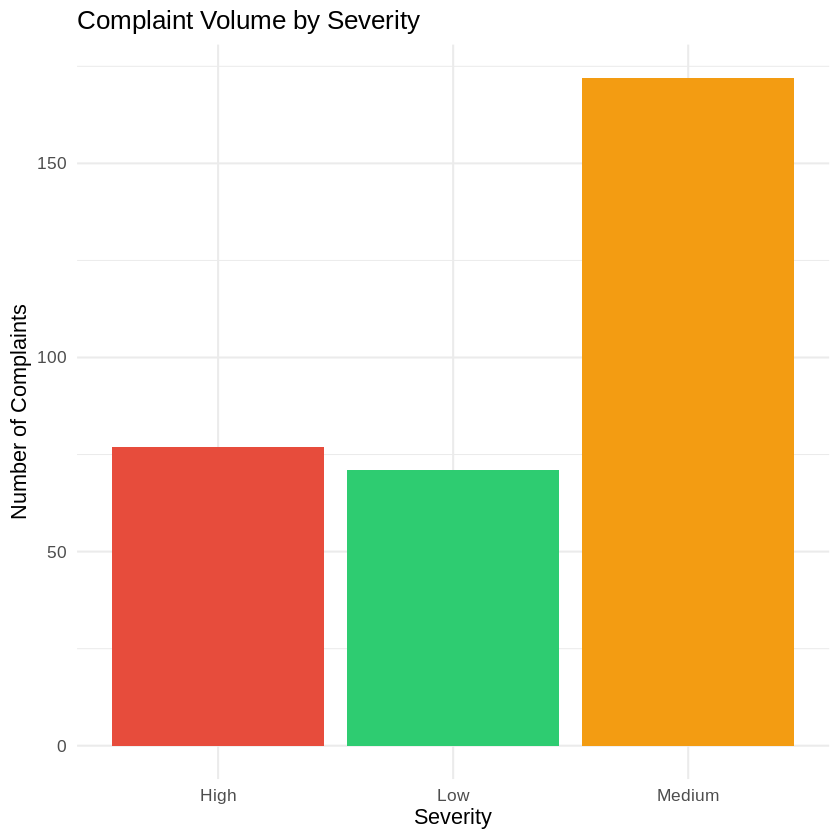

In [50]:
# count complaints by severity using dplyr
severity_counts <- complaints %>%
  filter(!is.na(severity)) %>%
  group_by(severity) %>%
  summarise(total = n(), .groups = "drop")

print(severity_counts)

# bar chart, one colour per severity
ggplot(severity_counts, aes(x = severity, y = total, fill = severity)) +
  geom_col(show.legend = FALSE) +
  scale_fill_manual(values = c("Low" = "#2ecc71", "Medium" = "#f39c12", "High" = "#e74c3c")) +
  labs(
    title = "Complaint Volume by Severity",
    x = "Severity",
    y = "Number of Complaints"
  ) +
  theme_minimal(base_size = 13)

Medium severity complaints account for the largest share of the total (172 out of 320, 54%), with High (77, 24%) and Low (71, 22%) roughly equal. The volume of medium severity cases suggests that most service failures are significant but not catastrophic. However with nearly a quarter of complaints rated high, there is still a substantial volume of issues requiring resolution, particularly delay and MissedPickup cases, which generate highest compensation costs.

### A3: Delivery failure rate by service type

In [51]:
# Distribution of service_type catches unexpected values and shows proportions
cat("service_type distribution in orders:\n")
print(table(orders$service_type, useNA = "always"))


# deliveries with no matching order  would be dropped by the left_join
unmatched <- sum(!deliveries$order_id %in% orders$order_id)
cat("\ndeliveries with no matching order:", unmatched,"\n")

service_type distribution in orders:

 Business   Medical    Parcel Passenger    Retail      <NA> 
      165       139       308       341       297         0 

deliveries with no matching order: 0 


# A tibble: 5 × 4
  service_type total failed fail_rate_pct
  <chr>        <int>  <int>         <dbl>
1 Business       126     25          19.8
2 Medical        108     16          14.8
3 Parcel         230     25          10.9
4 Passenger      262     38          14.5
5 Retail         224     28          12.5


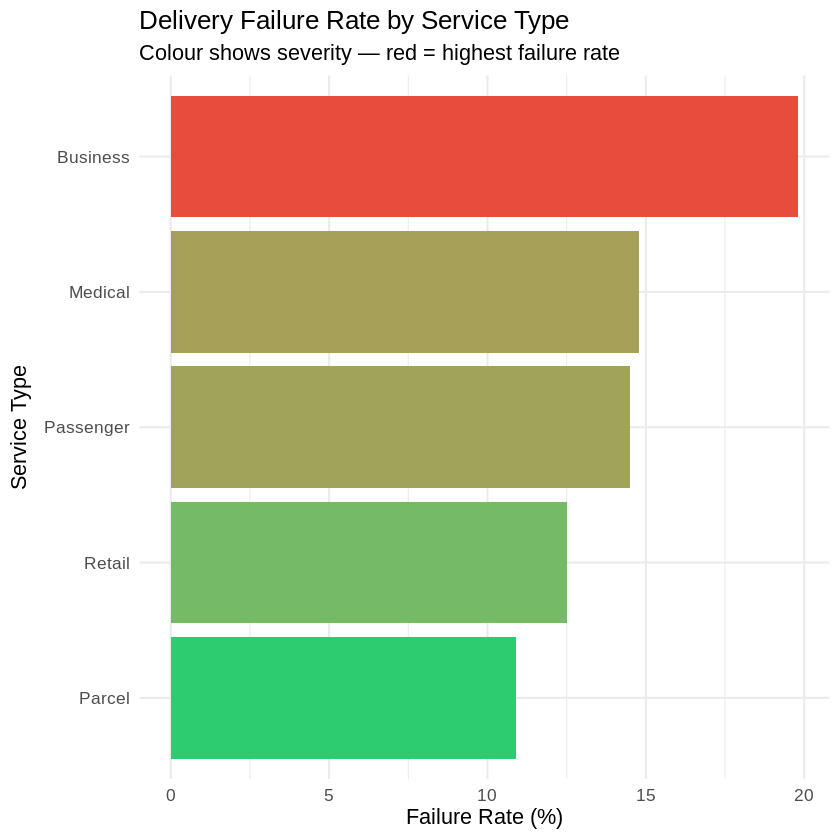

In [52]:
# Join deliveries to orders to get service_type
del_orders <- deliveries %>%
  left_join(orders[ , c("order_id", "service_type")], by = "order_id")

# group by service type, calculate failure rate with mutate()
service_fail <- del_orders %>%
  filter(!is.na(service_type)) %>%
  group_by(service_type) %>%
  summarise(
    total   = n(),
    failed  = sum(is_failed, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(fail_rate_pct = round(100 * failed / total, 1))

print(service_fail)

# bar chart ordered highest to lowest failure rate
ggplot(service_fail, aes(x = reorder(service_type, fail_rate_pct), y = fail_rate_pct, fill = fail_rate_pct)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  scale_fill_gradient(low = "#2ecc71", high = "#e74c3c") +
  labs(
    title = "Delivery Failure Rate by Service Type",
    subtitle = "Colour shows severity — red = highest failure rate",
    x = "Service Type",
    y = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 13)

The chart confirms that Business deliveries fail at almost twice the rate of Parcel deliveries. Medical services also underperform. Given that Business and Medical orders tend to carry higher values and are stricter around reliability, these failure rates represent higher risk. Parcel and Retail deliveries, which are more standardised appear to be handled more consistently.

### A4: Complaint resolution time by severity

In [53]:
# Check resolution_days for missing values and spread before plotting
cat("Resolution days summary:\n")
print(summary(complaints$resolution_days))
cat("\nMissing resolution_days:", sum(is.na(complaints$resolution_days)), "\n")

Resolution days summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.750   7.000   7.928  11.000  25.000 

Missing resolution_days: 0 


# A tibble: 3 × 4
  severity count median_days mean_days
  <fct>    <int>       <dbl>     <dbl>
1 Low         71           6       6.6
2 Medium     172           6       6.2
3 High        77          12      13.1


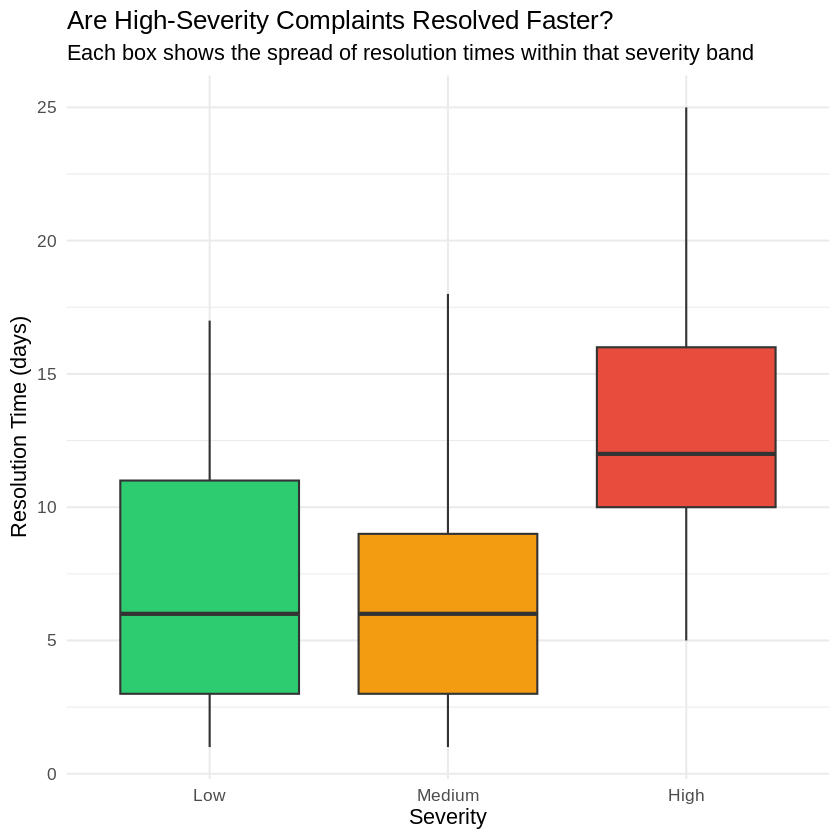

In [54]:
# Clean complaints remove rows missing resolution_days or severity
# factor with levels forces the correct Low, Medium, High order
complaints_clean <- complaints %>%
  filter(!is.na(resolution_days), !is.na(severity)) %>%
  mutate(severity = factor(severity, levels = c("Low", "Medium", "High")))

# Summary table: med and mean resolution time per severity band
resolution_summary <- complaints_clean %>%
  group_by(severity) %>%
  summarise(
    count       = n(),
    median_days = median(resolution_days),
    mean_days   = round(mean(resolution_days), 1),
    .groups     = "drop"
  )

print(resolution_summary)

# boxplot, one box per severity band
ggplot(complaints_clean, aes(x = severity, y = resolution_days, fill = severity)) +
  geom_boxplot(show.legend = FALSE, outlier.alpha = 0.4) +
  scale_fill_manual(values = c("Low" = "#2ecc71", "Medium" = "#f39c12", "High" = "#e74c3c")) +
  labs(
    title = "Are High-Severity Complaints Resolved Faster?",
    subtitle = "Each box shows the spread of resolution times within that severity band",
    x = "Severity",
    y = "Resolution Time (days)"
  ) +
  theme_minimal(base_size = 13)

The data shows a serious failure: high severity complaints take the longest to resolve, with a mean of 13.1 days and a median of 12 days, compared to just 6.2 days (mean) for medium and 6.6 days for low. This is the opposite of what good complaint management looks like, the most urgent cases are being resolved slowest. NorthStar's complaint handling process does not prioritise by severity, and this is likely contributing to customer issues.

### A5: Driver training score versus delivery failure rate

In [55]:
# Check how many drivers have enough deliveries for comparison
delivery_counts <- table(deliveries$driver_id)
cat("Drivers with 5+ deliveries:", sum(delivery_counts >= 5), "\n")
cat("Drivers with fewer than 5 deliveries:", sum(delivery_counts < 5), "\n")
cat("Drivers missing training score:", sum(is.na(drivers$training_score)), "\n")

Drivers with 5+ deliveries: 105 
Drivers with fewer than 5 deliveries: 65 
Drivers missing training score: 7 


Drivers included in analysis: 101 


driver_id,total_deliveries,total_failed,fail_rate,training_score
<chr>,<int>,<int>,<dbl>,<dbl>
D001,6,1,16.66667,67.8
D002,7,1,14.28571,42.4
D004,9,3,33.33333,88.9
D005,5,2,40.00000,69.7
D006,6,1,16.66667,78.8
D008,8,0,0.00000,84.1


`geom_smooth()` using formula = 'y ~ x'


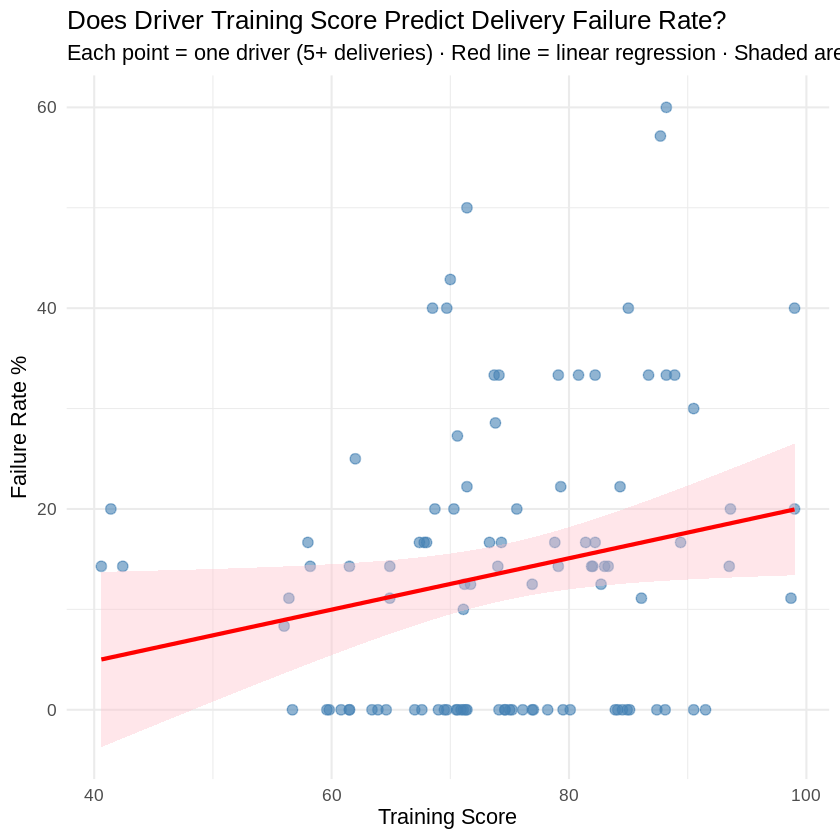

In [56]:
# summarise each driver's delivery record
driver_summary <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries = n(),
    total_failed     = sum(is_failed, na.rm = TRUE),
    fail_rate        = 100 * sum(is_failed, na.rm = TRUE) / n(),
    .groups          = "drop"
  ) %>%
  filter(total_deliveries >= 5)   # only drivers with enough data to be meaningful

# join in the training score from the drivers table
driver_summary <- driver_summary %>%
  left_join(drivers[ , c("driver_id", "training_score")], by = "driver_id") %>%
  filter(!is.na(training_score))

cat("Drivers included in analysis:", nrow(driver_summary), "\n")
head(driver_summary)

# scatter plot with OLS regression line
ggplot(driver_summary, aes(x = training_score, y = fail_rate)) +
  geom_point(colour = "steelblue", alpha = 0.6, size = 2.5) +
  geom_smooth(method = "lm", se = TRUE, colour = "red", fill = "pink") +
  labs(
    title = "Does Driver Training Score Predict Delivery Failure Rate?",
    subtitle = "Each point = one driver (5+ deliveries) · Red line = linear regression · Shaded area = 95% confidence",
    x = "Training Score",
    y = "Failure Rate %"
  ) +
  theme_minimal(base_size = 13)

The scatter plot shows no clear negative relationship between training score and failure rate. The regression line is nearly flat, and several high scoring drivers still fail frequently. For example, driver D004 holds a score of 88.9 yet fails 33% of deliveries. This means training score alone is not a reliable predictor of performance. Other factors like route difficulty, vehicle condition, or hub assignment appear to play a larger role in determining whether a delivery succeeds.

### A6: Complaint type breakdown

In [57]:
# Quick preview of complaint_type column
cat("Total complaints:", nrow(complaints), "\n")
cat("Missing complaint_type:", sum(is.na(complaints$complaint_type)), "\n")

Total complaints: 320 
Missing complaint_type: 0 


In [58]:
# Frequency table of complaint types, sorted highest to lowest
complaint_type_counts <- sort(table(complaints$complaint_type), decreasing = TRUE)

cat("Complaint type frequency:\n")
print(complaint_type_counts)

# What proportion does the top complaint type account for?
top_pct <- round(100 * max(complaint_type_counts) / sum(complaint_type_counts), 1)
cat("\nTop complaint type accounts for", top_pct, "% of all complaints\n")

Complaint type frequency:

            Delay      MissedPickup          AppIssue   DriverBehaviour 
              101                64                53                51 
SupportExperience           Billing            Damage 
               20                16                15 

Top complaint type accounts for 31.6 % of all complaints


Delay is the most common complaint, accounting for roughly a third of all cases recorded. This is consistent with the operational issues identified in the delivery failure analysis, if deliveries are frequently failing, delays to customers are the result. Missed pickups are also notable as the second most frequent complaint, suggesting problems at the point of collection.

### A7: Average order value by service type

In [59]:
# Check order_value range and any missing values
cat("Order value summary:\n")
print(summary(orders$order_value))
cat("\nMissing order_value:", sum(is.na(orders$order_value)), "\n")

Order value summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 

Missing order_value: 0 


# A tibble: 5 × 3
  service_type avg_value total_orders
  <chr>            <dbl>        <int>
1 Business          92.2          165
2 Medical           87.1          139
3 Parcel            87.6          308
4 Passenger         96.1          341
5 Retail            90.0          297


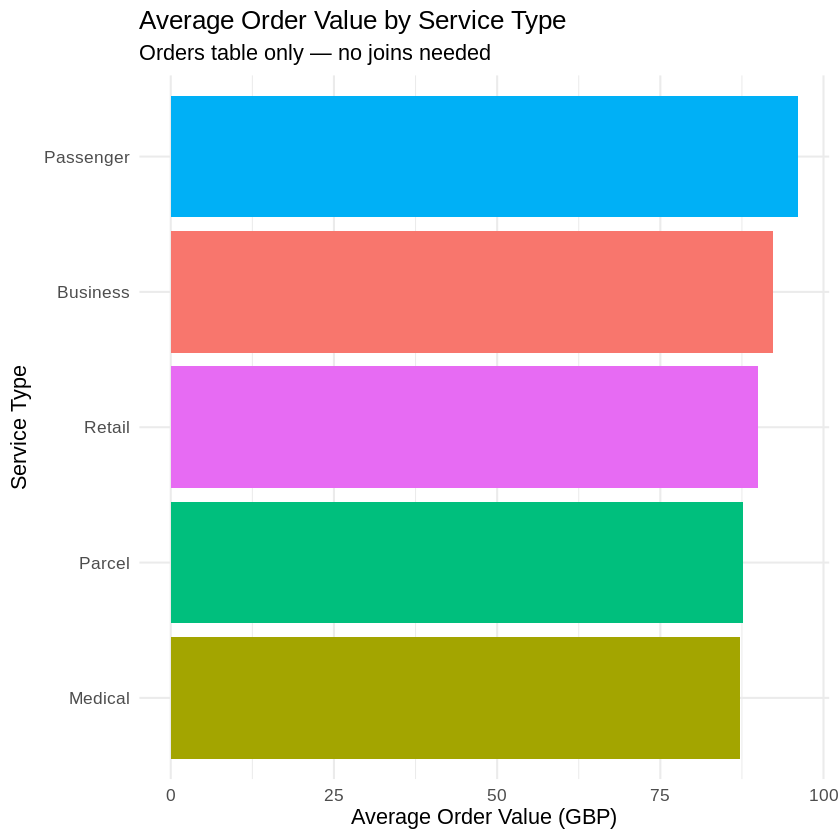

In [60]:
# Average order value per service type
avg_order_value <- orders %>%
  filter(!is.na(service_type), !is.na(order_value)) %>%
  group_by(service_type) %>%
  summarise(
    avg_value = round(mean(order_value), 2),
    total_orders = n(),
    .groups = "drop"
  )

print(avg_order_value)

# Bar chart — ordered highest to lowest average value
ggplot(avg_order_value, aes(x = reorder(service_type, avg_value), y = avg_value, fill = service_type)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Average Order Value by Service Type",
    subtitle = "Orders table only — no joins needed",
    x = "Service Type",
    y = "Average Order Value (GBP)"
  ) +
  theme_minimal(base_size = 13)

Business and Passenger orders carry the highest average values, while Medical and Retail orders are lower. Next to failure rate in Analysis 4, a clear risk emerges, business orders are both the most valuable and the most likely to fail. Improving reliability on Business deliveries would improve the revenue.